In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import numpy as np
import pandas as pd

DATASET_ROOT = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/Dataset_Li-ion"
FROZEN_DIR = f"/content/drive/MyDrive/frozen_dataset"
FEATURE_DIR = f"/content/drive/MyDrive/feature_engineering_v1"
BASELINE_DIR = f"/content/drive/MyDrive/day 15/baseline_v1"

TRAIN_PATH = f"/content/drive/MyDrive/frozen_dataset/dataset_v1_train.csv"
TEST_PATH = f"/content/drive/MyDrive/frozen_dataset/dataset_v1_test.csv"
ENGINEERED_PATH = f"/content/drive/MyDrive/feature_engineering_v1/engineered_dataset.csv"
BASELINE_METRICS_PATH = f"/content/drive/MyDrive/day 15/baseline_v1/baseline_metrics.csv"

for p in [TRAIN_PATH, TEST_PATH]:
    assert os.path.exists(p), f"Couldn't find {p} — check the Day 12 copy step."

TARGET_COLUMN = "soc_percent"
RAW_FEATURES = ["voltage_v", "current_a", "cell_temp_c", "power_w", "ambient_temp_c"]

df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw = pd.read_csv(TEST_PATH)
print(f"Frozen split loaded — train: {df_train_raw.shape}, test: {df_test_raw.shape}")

HAVE_ENGINEERED = os.path.exists(ENGINEERED_PATH)
if HAVE_ENGINEERED:
    df_eng_full = pd.read_csv(ENGINEERED_PATH)
    print(f"Engineered dataset found: {df_eng_full.shape}")
else:
    print("⚠️  Engineered dataset not found — only raw-feature ensembles will run.")

HAVE_BASELINE = os.path.exists(BASELINE_METRICS_PATH)
if HAVE_BASELINE:
    baseline_df = pd.read_csv(BASELINE_METRICS_PATH, index_col=0)
    print("\nDay 15 baseline metrics loaded for comparison:")
    print(baseline_df.to_string())
else:
    print("⚠️  baseline_metrics.csv not found — comparison table will only show today's models.")

Frozen split loaded — train: (76792, 7), test: (27768, 7)
Engineered dataset found: (104525, 5)

Day 15 baseline metrics loaded for comparison:
                           MAE       RMSE        R2  MAE_improvement_vs_mean_%
label                                                                         
Mean baseline        23.041381  27.508849 -0.047575                   0.000000
Linear — raw          3.472758   4.585786  0.970888                  84.928169
Linear — engineered  23.193436  27.771279 -0.068143                  -0.659925


In [3]:
ENGINEERED_FEATURES = None
if HAVE_ENGINEERED:
    key_cols = ["file_id", "timestamp"]
    eng_cols = [c for c in df_eng_full.columns if c not in key_cols + [TARGET_COLUMN]]

    train_ids = df_train_raw["file_id"].unique()
    test_ids = df_test_raw["file_id"].unique()

    df_eng_train = df_eng_full[df_eng_full["file_id"].isin(train_ids)].copy()
    df_eng_test = df_eng_full[df_eng_full["file_id"].isin(test_ids)].copy()

    ENGINEERED_FEATURES = eng_cols
    print(f"\nEngineered features available ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")
    print(f"Engineered train/test after routing by file_id: "
          f"{df_eng_train.shape} / {df_eng_test.shape}")


Engineered features available (2): ['voltage_roll_std5', 'current_roll_std5']
Engineered train/test after routing by file_id: (76764, 5) / (27761, 5)


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"label": label, "MAE": mae, "RMSE": rmse, "R2": r2}

def score_train_test(model, X_train, y_train, X_test, y_test, label):
    """Scores on BOTH train and test so overfitting shows up as a gap,
    not something we have to eyeball from a single number."""
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    train_metrics = score(y_train, pred_train, f"{label} (train)")
    test_metrics = score(y_test, pred_test, f"{label} (test)")
    gap_mae = test_metrics["MAE"] - train_metrics["MAE"]
    print(f"[{label}] train MAE={train_metrics['MAE']:.3f}  test MAE={test_metrics['MAE']:.3f}  "
          f"gap={gap_mae:+.3f}  |  train R2={train_metrics['R2']:.4f}  test R2={test_metrics['R2']:.4f}")
    return train_metrics, test_metrics, pred_test

all_results = []
predictions = {}
fitted_models = {}
model_params = {}

In [5]:
try:
    from xgboost import XGBRegressor
    GB_MODEL_NAME = "XGBoost"
    def make_gb_model():
        return XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
        )
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    GB_MODEL_NAME = "GradientBoosting"
    print("⚠️  xgboost not installed — falling back to sklearn's "
          "GradientBoostingRegressor. `!pip install xgboost` to use XGBoost instead.")
    def make_gb_model():
        return GradientBoostingRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42,
        )

from sklearn.ensemble import RandomForestRegressor

def make_rf_model():
    return RandomForestRegressor(
        n_estimators=300, max_depth=14, min_samples_leaf=2,
        random_state=42, n_jobs=-1,
    )

In [7]:
X_train_raw = df_train_raw[RAW_FEATURES]
X_test_raw = df_test_raw[RAW_FEATURES]

print("\n===== RANDOM FOREST — raw features =====")
rf_raw = make_rf_model()
rf_raw.fit(X_train_raw, y_train := df_train_raw[TARGET_COLUMN])
tr_m, te_m, pred = score_train_test(rf_raw, X_train_raw, y_train, X_test_raw, df_test_raw[TARGET_COLUMN], "RandomForest — raw")
all_results += [tr_m, te_m]
predictions["RandomForest_raw"] = pred
fitted_models["RandomForest_raw"] = rf_raw
model_params["RandomForest_raw"] = rf_raw.get_params()

print(f"\n===== {GB_MODEL_NAME.upper()} — raw features =====")
gb_raw = make_gb_model()
gb_raw.fit(X_train_raw, y_train)
tr_m, te_m, pred = score_train_test(gb_raw, X_train_raw, y_train, X_test_raw, df_test_raw[TARGET_COLUMN], f"{GB_MODEL_NAME} — raw")
all_results += [tr_m, te_m]
predictions[f"{GB_MODEL_NAME}_raw"] = pred
fitted_models[f"{GB_MODEL_NAME}_raw"] = gb_raw
model_params[f"{GB_MODEL_NAME}_raw"] = gb_raw.get_params()


===== RANDOM FOREST — raw features =====
[RandomForest — raw] train MAE=0.884  test MAE=3.284  gap=+2.400  |  train R2=0.9953  test R2=0.8481

===== XGBOOST — raw features =====
[XGBoost — raw] train MAE=1.325  test MAE=3.301  gap=+1.975  |  train R2=0.9917  test R2=0.8593


In [8]:
if HAVE_ENGINEERED:
    X_train_eng = df_eng_train[ENGINEERED_FEATURES]
    y_train_eng = df_eng_train[TARGET_COLUMN]
    X_test_eng = df_eng_test[ENGINEERED_FEATURES]
    y_test_eng = df_eng_test[TARGET_COLUMN]

    print("\n===== RANDOM FOREST — engineered features =====")
    rf_eng = make_rf_model()
    rf_eng.fit(X_train_eng, y_train_eng)
    tr_m, te_m, pred = score_train_test(rf_eng, X_train_eng, y_train_eng, X_test_eng, y_test_eng, "RandomForest — engineered")
    all_results += [tr_m, te_m]
    predictions["RandomForest_engineered"] = pred
    fitted_models["RandomForest_engineered"] = rf_eng
    model_params["RandomForest_engineered"] = rf_eng.get_params()

    print(f"\n===== {GB_MODEL_NAME.upper()} — engineered features =====")
    gb_eng = make_gb_model()
    gb_eng.fit(X_train_eng, y_train_eng)
    tr_m, te_m, pred = score_train_test(gb_eng, X_train_eng, y_train_eng, X_test_eng, y_test_eng, f"{GB_MODEL_NAME} — engineered")
    all_results += [tr_m, te_m]
    predictions[f"{GB_MODEL_NAME}_engineered"] = pred
    fitted_models[f"{GB_MODEL_NAME}_engineered"] = gb_eng
    model_params[f"{GB_MODEL_NAME}_engineered"] = gb_eng.get_params()
else:
    print("\n(Skipping engineered-feature ensembles — engineered_dataset.csv not found.)")


===== RANDOM FOREST — engineered features =====
[RandomForest — engineered] train MAE=19.101  test MAE=22.943  gap=+3.842  |  train R2=0.2903  test R2=-0.1581

===== XGBOOST — engineered features =====
[XGBoost — engineered] train MAE=20.949  test MAE=22.599  gap=+1.649  |  train R2=0.2017  test R2=-0.0495


In [9]:
results_df = pd.DataFrame(all_results).set_index("label")
print("\n===== FULL TRAIN vs. TEST RESULTS =====")
print(results_df.to_string())


overfit_rows = []
model_labels = ["RandomForest — raw", f"{GB_MODEL_NAME} — raw"]
if HAVE_ENGINEERED:
    model_labels += ["RandomForest — engineered", f"{GB_MODEL_NAME} — engineered"]

for label in model_labels:
    train_row = results_df.loc[f"{label} (train)"]
    test_row = results_df.loc[f"{label} (test)"]
    gap = test_row["MAE"] - train_row["MAE"]
    verdict = (
        "possible overfitting" if gap > 0.5 * train_row["MAE"] else
        "underfitting (both scores weak)" if train_row["R2"] < 0.6 else
        "looks reasonable"
    )
    overfit_rows.append({
        "model": label, "train_MAE": train_row["MAE"], "test_MAE": test_row["MAE"],
        "MAE_gap": gap, "train_R2": train_row["R2"], "test_R2": test_row["R2"], "verdict": verdict,
    })

overfit_df = pd.DataFrame(overfit_rows).set_index("model")
print("\n===== OVERFIT / UNDERFIT CHECK =====")
print(overfit_df.to_string())
print("\nRule of thumb used here: MAE gap over half the training MAE gets flagged as "
      "possible overfitting; weak train R^2 (<0.6) gets flagged as underfitting. "
      "Treat these as prompts for the mentor conversation, not a final verdict.")



===== FULL TRAIN vs. TEST RESULTS =====
                                         MAE       RMSE        R2
label                                                            
RandomForest — raw (train)          0.884200   1.903391  0.995334
RandomForest — raw (test)           3.284465  10.474381  0.848121
XGBoost — raw (train)               1.325229   2.532821  0.991738
XGBoost — raw (test)                3.300615  10.082012  0.859287
RandomForest — engineered (train)  19.101003  23.470194  0.290279
RandomForest — engineered (test)   22.942698  28.916572 -0.158060
XGBoost — engineered (train)       20.949292  24.891887  0.201693
XGBoost — engineered (test)        22.598706  27.527405 -0.049465

===== OVERFIT / UNDERFIT CHECK =====
                           train_MAE   test_MAE   MAE_gap  train_R2   test_R2                          verdict
model                                                                                                         
RandomForest — raw          0.884200   

In [10]:
if HAVE_BASELINE:
    test_only = results_df[results_df.index.str.endswith("(test)")].copy()
    test_only.index = test_only.index.str.replace(" (test)", "", regex=False)
    combined = pd.concat([baseline_df[["MAE", "RMSE", "R2"]], test_only[["MAE", "RMSE", "R2"]]])
    print("\n===== BASELINES (Day 15) vs. ENSEMBLES (Day 16), test set =====")
    print(combined.sort_values("MAE").to_string())


===== BASELINES (Day 15) vs. ENSEMBLES (Day 16), test set =====
                                 MAE       RMSE        R2
label                                                    
RandomForest — raw          3.284465  10.474381  0.848121
XGBoost — raw               3.300615  10.082012  0.859287
Linear — raw                3.472758   4.585786  0.970888
XGBoost — engineered       22.598706  27.527405 -0.049465
RandomForest — engineered  22.942698  28.916572 -0.158060
Mean baseline              23.041381  27.508849 -0.047575
Linear — engineered        23.193436  27.771279 -0.068143


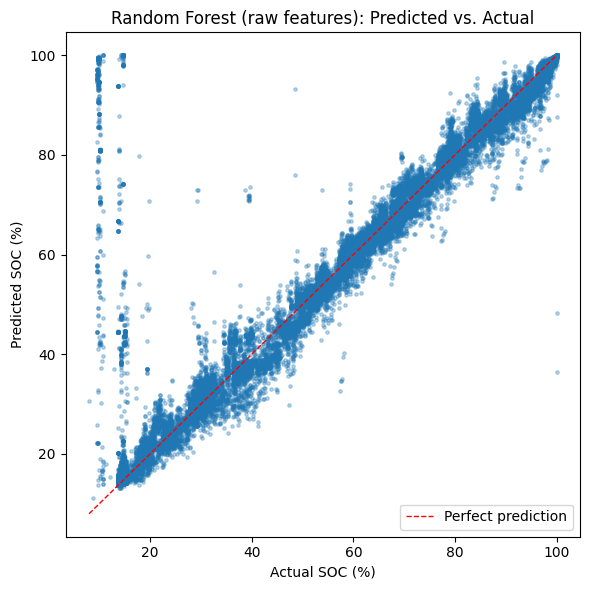

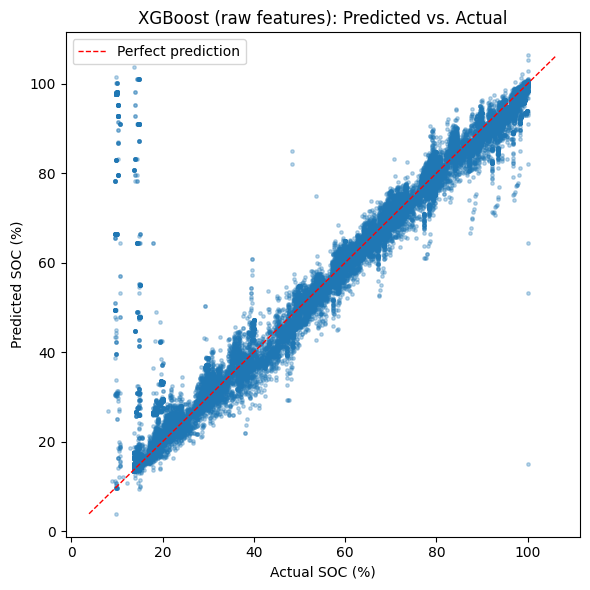

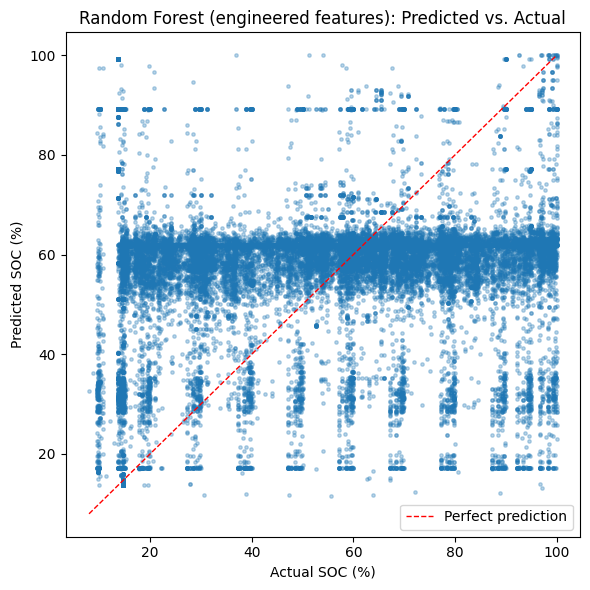

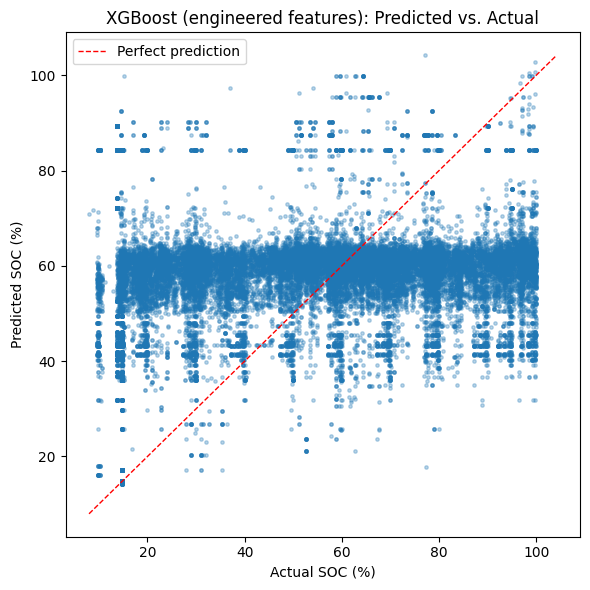

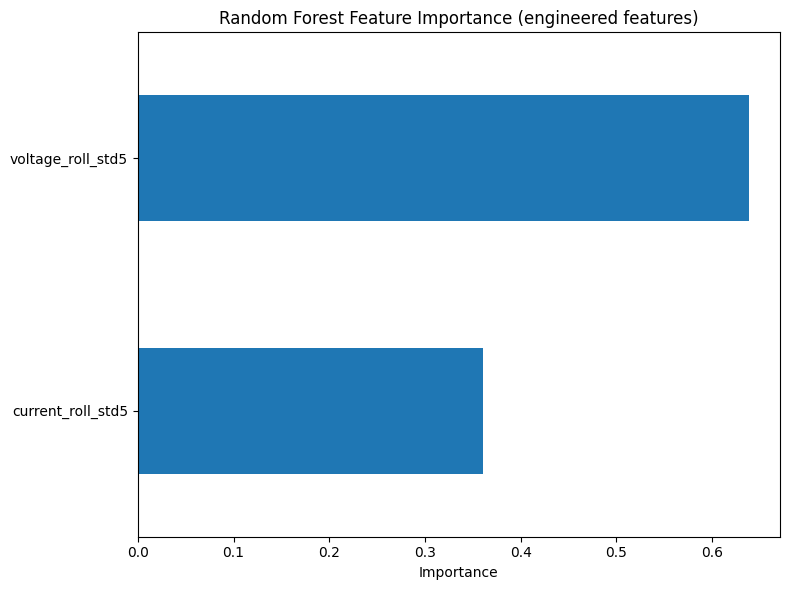

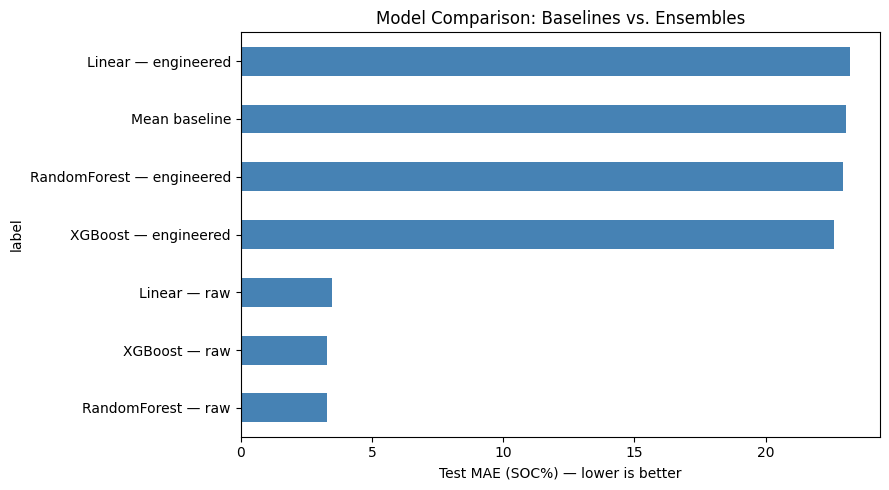


✅ Plots saved in 'ensemble_v1/':
 - feature_importance_rf_engineered.png
 - model_comparison_mae.png
 - pred_vs_actual_rf_engineered.png
 - pred_vs_actual_rf_raw.png
 - pred_vs_actual_xgboost_engineered.png
 - pred_vs_actual_xgboost_raw.png


In [11]:
import matplotlib.pyplot as plt

os.makedirs("ensemble_v1", exist_ok=True)
os.makedirs("ensemble_v1/models", exist_ok=True)

def plot_pred_vs_actual(y_true, y_pred, title, filename):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=6, alpha=0.3)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
    plt.xlabel("Actual SOC (%)")
    plt.ylabel("Predicted SOC (%)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"ensemble_v1/{filename}", dpi=150)
    plt.show()

plot_pred_vs_actual(df_test_raw[TARGET_COLUMN], predictions["RandomForest_raw"],
                     "Random Forest (raw features): Predicted vs. Actual", "pred_vs_actual_rf_raw.png")
plot_pred_vs_actual(df_test_raw[TARGET_COLUMN], predictions[f"{GB_MODEL_NAME}_raw"],
                     f"{GB_MODEL_NAME} (raw features): Predicted vs. Actual", f"pred_vs_actual_{GB_MODEL_NAME.lower()}_raw.png")
if HAVE_ENGINEERED:
    plot_pred_vs_actual(y_test_eng, predictions["RandomForest_engineered"],
                         "Random Forest (engineered features): Predicted vs. Actual", "pred_vs_actual_rf_engineered.png")
    plot_pred_vs_actual(y_test_eng, predictions[f"{GB_MODEL_NAME}_engineered"],
                         f"{GB_MODEL_NAME} (engineered features): Predicted vs. Actual", f"pred_vs_actual_{GB_MODEL_NAME.lower()}_engineered.png")


if HAVE_ENGINEERED:
    importances = pd.Series(rf_eng.feature_importances_, index=ENGINEERED_FEATURES).sort_values()
    plt.figure(figsize=(8, 6))
    importances.plot(kind="barh")
    plt.xlabel("Importance")
    plt.title("Random Forest Feature Importance (engineered features)")
    plt.tight_layout()
    plt.savefig("ensemble_v1/feature_importance_rf_engineered.png", dpi=150)
    plt.show()


compare_source = combined if HAVE_BASELINE else results_df[results_df.index.str.endswith("(test)")]
plt.figure(figsize=(9, 5))
compare_source["MAE"].sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Test MAE (SOC%) — lower is better")
plt.title("Model Comparison: Baselines vs. Ensembles")
plt.tight_layout()
plt.savefig("ensemble_v1/model_comparison_mae.png", dpi=150)
plt.show()

print("\n✅ Plots saved in 'ensemble_v1/':")
for f in sorted(os.listdir("ensemble_v1")):
    if f.endswith(".png"):
        print(" -", f)

In [15]:
import joblib


pred_out = df_test_raw[["file_id", TARGET_COLUMN]].copy()
pred_out["pred_RandomForest_raw"] = predictions["RandomForest_raw"]
pred_out[f"pred_{GB_MODEL_NAME}_raw"] = predictions[f"{GB_MODEL_NAME}_raw"]
pred_out.to_csv("ensemble_v1/predictions_raw_features.csv", index=False)

if HAVE_ENGINEERED:
    pred_out_eng = df_eng_test[["file_id", "timestamp", TARGET_COLUMN]].copy()
    pred_out_eng["pred_RandomForest_engineered"] = predictions["RandomForest_engineered"]
    pred_out_eng[f"pred_{GB_MODEL_NAME}_engineered"] = predictions[f"{GB_MODEL_NAME}_engineered"]
    pred_out_eng.to_csv("ensemble_v1/predictions_engineered_features.csv", index=False)


def jsonable_params(params):
    return {k: (v if isinstance(v, (int, float, str, bool)) or v is None else str(v))
            for k, v in params.items()}

with open("ensemble_v1/model_parameters.json", "w") as f:
    json.dump({name: jsonable_params(p) for name, p in model_params.items()}, f, indent=2)


for name, model in fitted_models.items():
    joblib.dump(model, f"ensemble_v1/models/{name}.joblib")

results_df.to_csv("ensemble_v1/train_test_metrics.csv")
overfit_df.to_csv("ensemble_v1/overfit_check.csv")
if HAVE_BASELINE:
    combined.to_csv("ensemble_v1/baseline_vs_ensemble_comparison.csv")

print("\n✅ Model artifacts saved in 'ensemble_v1/models/':")
for f in sorted(os.listdir("ensemble_v1/models")):
    print(" -", f)


✅ Model artifacts saved in 'ensemble_v1/models/':
 - RandomForest_engineered.joblib
 - RandomForest_raw.joblib
 - XGBoost_engineered.joblib
 - XGBoost_raw.joblib


In [16]:
import datetime

best_model = (combined if HAVE_BASELINE else results_df[results_df.index.str.endswith("(test)")])["MAE"].idxmin()

with open("ensemble_v1/summary.txt", "w") as f:
    f.write("Day 16 — Ensemble Models\n")
    f.write(f"Generated: {datetime.datetime.now()}\n\n")
    f.write("Split used: SAME frozen Dataset V1 split as Day 12/15 (GroupShuffleSplit "
            "by file_id, test_size=0.2, random_state=42).\n")
    f.write(f"Gradient boosting implementation used: {GB_MODEL_NAME}\n")
    f.write("Agreed metrics: MAE (SOC%), RMSE (SOC%), R^2 — scored on both train and test.\n\n")
    f.write("Train vs. test metrics:\n")
    f.write(results_df.to_string())
    f.write("\n\nOverfit / underfit check:\n")
    f.write(overfit_df.to_string())
    if HAVE_BASELINE:
        f.write("\n\nBaselines vs. ensembles (test set):\n")
        f.write(combined.sort_values("MAE").to_string())
    f.write(f"\n\nBest model on test MAE: {best_model}\n")
    f.write("\nModelling direction:\n")
    f.write(" - If the best ensemble beats the Day 15 linear baselines by a clear margin,\n"
            "   that confirms tree-based models are worth carrying forward.\n"
            " - Check the overfit_check.csv verdicts before picking a model to tune further —\n"
            "   a model with a small train/test gap and solid R^2 is a safer starting point\n"
            "   than the single lowest test MAE if that model is also badly overfit.\n"
            " - Feature importance (engineered set) is saved as a plot — useful for deciding\n"
            "   which Day 13 features are worth keeping if the feature list gets trimmed later.\n")

print("\n✅ Summary written to 'ensemble_v1/summary.txt'")
print(f"Best model on test MAE: {best_model}")


✅ Summary written to 'ensemble_v1/summary.txt'
Best model on test MAE: RandomForest — raw


In [17]:
import shutil
shutil.copytree("ensemble_v1", "/content/drive/MyDrive/Dataset_Li-ion/ensemble_v1", dirs_exist_ok=True)

'/content/drive/MyDrive/Dataset_Li-ion/ensemble_v1'